# 第十九天知识点总结：最大似然估计（Maximum Likelihood Estimation, MLE）

## 1. 核心思想
- **MLE**：给定观测数据，找到使这些数据出现概率（似然）最大的模型参数。
- 通俗理解：**“结果已知，反推最可能的原因”**。
- 与概率的区别：
  - 概率：已知参数，预测数据出现的可能性。
  - 似然：已知数据，评估不同参数下数据出现的可能性。

## 2. 似然函数与对数似然
- **似然函数**  
$$
L(\theta) = \prod_{i=1}^{n} P(x_i; \theta) \quad (\text{离散}) \quad \text{或} \quad L(\theta) = \prod_{i=1}^{n} f(x_i; \theta) \quad (\text{连续})
$$

- **对数似然**  
$$
\ell(\theta) = \ln L(\theta) = \sum_{i=1}^{n} \ln f(x_i; \theta)
$$

  - 将乘积变为求和，便于求导和优化。

## 3. 经典分布的 MLE 结果

| 分布 | 参数 | MLE 估计量 |
|------|------|-------------|
| 伯努利（抛硬币） | $p$（正面概率） | $\hat{p} = \frac{k}{n}$（$k$ 次正面，$n$ 次试验） |
| 正态分布 | $\mu$（均值） | $\hat{\mu} = \frac{1}{n}\sum_{i=1}^{n} x_i$（样本均值） |
| 正态分布 | $\sigma^2$（方差） | $\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^2$（有偏样本方差） |

## 4. MLE 与机器学习的关系
- **线性回归**：假设误差服从正态分布 $\epsilon \sim \mathcal{N}(0, \sigma^2)$，则 **MLE 等价于最小二乘法**。
- **逻辑回归**：最大化对数似然
$$
\ell(\theta) = \sum_{i=1}^{n} \big[y_i \ln p_i + (1-y_i) \ln(1-p_i)\big]
$$
推导出**交叉熵损失函数**。
- **深度学习**：分类任务中常用交叉熵损失，本质上是最大化似然。

## 5. 求解 MLE 的常用方法
- **解析法**：对似然函数求导，令导数为 0，解出参数（如正态分布、伯努利分布）。
- **数值优化**：当没有解析解时，用梯度下降、牛顿法等迭代求解（如逻辑回归）。

## 6. MLE、MAP 与贝叶斯估计的区别

| 方法 | 公式 | 特点 |
|------|------|------|
| MLE | $\hat{\theta} = \arg\max\limits_{\theta} P(D \mid \theta)$ | 仅依赖数据，无先验 |
| MAP | $\hat{\theta} = \arg\max\limits_{\theta} P(\theta \mid D)$ | 引入先验 $P(\theta)$，相当于 MLE + 正则化 |
| 贝叶斯估计 | $P(\theta \mid D) = \frac{P(D \mid \theta)P(\theta)}{P(D)}$ | 计算后验分布，而非单点估计 |

## 7. 重要性质
- **一致性**：样本量 $n \to \infty$ 时，$\hat{\theta}_{\text{MLE}} \to \theta_{\text{true}}$。
- **渐近正态性**：大样本下
$$
\sqrt{n}\big(\hat{\theta}_{\text{MLE}} - \theta_0\big) \xrightarrow{d} \mathcal{N}\big(0, \mathcal{I}(\theta_0)^{-1}\big)
$$
其中 $\mathcal{I}(\theta_0)$ 是 Fisher 信息量。

- **不变性**：若 $\hat{\theta}$ 是 $\theta$ 的 MLE，则对任意函数 $g(\theta)$，$g(\hat{\theta})$ 也是 $g(\theta)$ 的 MLE。

## 8. 代码实践要点
- 抛硬币 MLE：`p_hat = np.mean(flips)`
- 正态分布 MLE：`mu_hat = np.mean(data); sigma_hat = np.std(data, ddof=0)`
- 使用 `scipy.stats.norm.fit(data)` 可直接返回 MLE 估计的 $\mu$ 和 $\sigma$。
- 通过模拟验证：不断增加样本量，观察估计值收敛到真实参数。


估计概率为：0.591


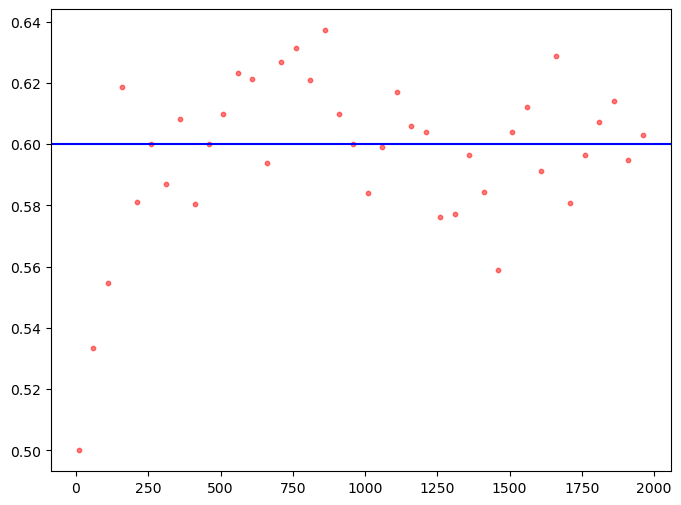

In [35]:
## 练习1：抛硬币MLE模拟

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# 模拟抛掷次数 n 从 10 到 2000 ，步长 50。
n_list=range(10,2001,50)
p_true=0.6
p_hat_list=[]

#对每个 n，进行一次抛掷实验，计算p^
for n in n_list:
    D=np.random.choice([1,0],size=n,p=[p_true,1-p_true])
    p_hat_list.append(np.sum(D)/n)
print(f"估计概率为：{np.sum(D)/2000}")

# 画出 p^ 随 n 变化的散点图，同时绘制真实概率p=0.6 的水平线
plt.figure(figsize=(8,6))
plt.scatter(n_list,p_hat_list,color='r',alpha=0.5,s=10)
plt.axhline(y=p_true,color='b',linestyle='-')
plt.show()




In [ ]:
## 练习2：正态分布 MLE 验证

import numpy as np
import scipy
import matplotlib.pyplot as plt

# 随机生成数据
np.random.seed(42) # 固定随机种子，让每次运行生成的随机数完全一样
n=1000
data=np.random.normal(loc=5,scale=2,size=n)

# 手动计算 MLE 估计：

mu_hat=np.mean(data)
sigma_hat=np.std(data)
print(f"mu^ : {mu_hat:.2f} \n sigma^ : {sigma_hat:.4f}")

# 使用scipy.stats.norm.fit(data) 得到拟合参数，对比是否相同

mu,sigma=scipy.stats.norm.fit(data)
print(f"mu : {mu:.2f} \n sigma : {sigma:.4f}")

print(abs(mu_hat-5))
print(abs(sigma_hat-2))



mu^ : 5.04 
 sigma^ : 1.9575
mu : 5.04 
 sigma : 1.9575
0.038664111644651555
0.04254758450529139


In [34]:
## 练习3：从零实现正态分布 MLE 的数值优化
import numpy as np
from scipy.optimize import minimize
import math

# 生成模拟正态数据
np.random.seed(42)
true_mu=2.0
true_sigma=1.5
data=np.random.normal(loc=true_mu,scale=true_sigma,size=1000)
n=len(data)

# 定义负对数似然函数 NLL
def neg_log_likehood(params,data):
    mu,sigma=params

    # 约束 sigma > 0 避免报错
    if params[1]<=0:
        return 1e10
    nll=n/2*np.log(2*np.pi)+n*np.log(sigma)+1/(2*sigma**2)*np.sum((data-mu)**2)
    return nll

# 数据优化求解 MLE
init_params=[0.0,1.0] # 初始值[mu,sigma]
#约束 sigma > 0
bounds=((None,None),(1e-6,None))
res=minimize(neg_log_likehood,init_params,args=(data,),bounds=bounds)
mu_analytic=np.mean(data)
sigma_analytic=np.std(data,ddof=0)

print("======数据优化结果（最小化负对数似然）======")
print(f"估计 mu:{res.x[0]:.4f}")
print(f"估计 sigma:{res.x[1]:.4f}")
print("\n=======解析解（理论 MLE )=======")
print(f"解析 mu:{mu_analytic:.4f}")
print(f"解析 sigma:{sigma_analytic:.4f}")
print("\n======真实生成参数=======")
print(f"真实mu:{true_mu}")
print(f"真实sigma：{true_sigma}")
print(res.fun)

======数据优化结果（最小化负对数似然）======
估计 mu:2.0290
估计 sigma:1.4681

=======解析解（理论 MLE )=======
解析 mu:2.0290
解析 sigma:1.4681

======真实生成参数=======
真实mu:2.0
真实sigma：1.5
1802.900300525657


## 1. scipy.optimize.minimize 核心用法
专门用于求多元函数的最小值，这里用来最小化负对数似然
基础用法：
### minimize(fun, x0, args=(), bounds=None, method=None)

fun ：要最小化的目标函数
x0 ： 优化的初始值
args ： 目标函数的而外参数（元组）（这里的 args=(data,) 多一个“ , ”是为了把它识别成元组
bounds ： 参数的取值范围约束（格式是（（参数 1 下界，参数 1 上界），（参数 2 下界，参数 2 上界）），Noen 表示无约束）

### minimize 返回的 res 对象包含优化的所有信息，常用属性：
| 属性 | 作用 | 本例使用场景 |
| ---- | ---- | ------------ |
| res.x | 最优参数数组 | res.x[0] 为估计 mu，res.x[1] 为估计 sigma |
| res.fun | 目标函数最小取值 | 本次最小负对数似然值 |
| res.success | 布尔值，判断是否收敛成功 | 检验优化是否正常完成 |
| res.message | 优化过程提示信息 | 查看收敛/报错原因 |

## 一、前提设定
设独立同分布样本：$x_1,x_2,\dots,x_n \sim N(\mu,\sigma^2)$
单变量正态分布概率密度函数（PDF）：
$$
f(x;\mu,\sigma) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left\{ -\frac{(x-\mu)^2}{2\sigma^2} \right\}
$$
待估参数：$\boldsymbol{\theta} = (\mu,\sigma),\ \sigma>0$

## 二、构造似然函数
样本相互独立，**联合概率密度 = 各样本密度乘积**，即似然函数：
$$
L(\mu,\sigma) = \prod_{i=1}^n f(x_i;\mu,\sigma)
$$

代入 PDF：
$$
L(\mu,\sigma) 
= \prod_{i=1}^n \frac{1}{\sqrt{2\pi}\sigma} \exp\left\{ -\frac{(x_i-\mu)^2}{2\sigma^2} \right\}
$$

展开乘积：
$$
L(\mu,\sigma)
= \left( \frac{1}{\sqrt{2\pi}\sigma} \right)^n
\exp\left\{ -\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2 \right\}
$$

## 三、对数似然函数（取自然对数）
乘积转求和、简化求导，定义**对数似然** $\ell = \ln L$：
$$
\ell(\mu,\sigma)
= n\ln\left(\frac{1}{\sqrt{2\pi}\sigma}\right)
- \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2
$$

拆分化简：
$$
\ell(\mu,\sigma)
= -\frac{n}{2}\ln(2\pi) - n\ln\sigma
- \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2
$$

## 四、负对数似然（NLL）
数值优化时一般**最小化负对数似然**：
$$
\text{NLL} = -\ell(\mu,\sigma)
= \frac{n}{2}\ln(2\pi) + n\ln\sigma
+ \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2
$$
> 与代码中使用的公式完全一致。

## 五、求极大似然估计（解析解）
极大似然：$\displaystyle \max_{\mu,\sigma}\ \ell(\mu,\sigma)$
对参数分别求偏导，令偏导 = 0。

### 1. 对 $\mu$ 求偏导并置0
$$
\frac{\partial \ell}{\partial \mu}
= -\frac{1}{2\sigma^2} \cdot \sum_{i=1}^n 2(x_i-\mu)\cdot(-1)
= \frac{1}{\sigma^2}\sum_{i=1}^n (x_i-\mu) = 0
$$

约去 $\dfrac{1}{\sigma^2}$：
$$
\sum_{i=1}^n (x_i - \mu) = 0
$$
$$
\sum_{i=1}^n x_i - n\mu = 0
$$

解得 **均值 MLE**：
$$
\hat{\mu}_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^n x_i = \bar{x}
$$

### 2. 对 $\sigma$ 求偏导并置0
先求导：
$$
\frac{\partial \ell}{\partial \sigma}
= -\frac{n}{\sigma}
+ \frac{1}{\sigma^3}\sum_{i=1}^n (x_i-\mu)^2 = 0
$$

移项：
$$
\frac{n}{\sigma} = \frac{1}{\sigma^3}\sum_{i=1}^n (x_i-\mu)^2
$$

两边同乘 $\sigma^3$：
$$
n\sigma^2 = \sum_{i=1}^n (x_i-\mu)^2
$$

将已求得的 $\hat{\mu}=\bar{x}$ 代入，解得**方差 & 标准差 MLE**：
$$
\hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^2
$$
$$
\hat{\sigma}_{\text{MLE}} = \sqrt{\,\frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^2\,}
$$

## 六、结论
正态分布参数极大似然估计解析解：
1. 均值：$\boldsymbol{\hat{\mu} = \bar{x}}$（样本均值）
2. 标准差：$\boldsymbol{\hat{\sigma} = \sqrt{\dfrac{1}{n}\displaystyle\sum_{i=1}^n (x_i-\bar{x})^2}}$

> 代码中 `np.std(data, ddof=0)` 正是该公式实现。